# Intuitive Financial Fraud Detection System


## Life Cycle and Development Process
**Phase 1: Data Collection and Preprocessing**
The first phase involves acquiring and preparing the data.

- Data Acquisition: A large dataset of historical financial transactions will be collected. This dataset should include both legitimate and fraudulent transactions, and contain features such as transaction amount, time, location, merchant category, and account history.

- Data Cleaning and Feature Engineering: The raw data will be cleaned to handle missing values and inconsistencies. New features will be engineered from existing data to improve the model's performance. For example, a new feature could be created to calculate the average transaction amount for a user over a specific time period, or the frequency of transactions from a new location.

- Addressing Class Imbalance: Since fraudulent transactions are rare, the dataset will be highly imbalanced. This issue will be addressed using techniques like SMOTE (Synthetic Minority Over-sampling Technique) or similar methods to balance the dataset before model training.

**Phase 2: Model Building and Training**
This phase focuses on developing and optimizing the machine learning model.

- Model Selection: Various machine learning algorithms will be tested to determine the most effective one for this task. Potential candidates include Random Forest, Gradient Boosting Machines, and Neural Networks. The performance of each model will be evaluated based on metrics suitable for imbalanced datasets, such as the F1-score, precision, and recall.

- Model Training: The selected model will be trained on the preprocessed dataset. Cross-validation will be used to ensure the model's robustness and to prevent overfitting.

- Model Optimization: The model's hyperparameters will be tuned to improve its accuracy and efficiency. This will involve using techniques like grid search or randomized search to find the optimal combination of parameters. The goal is to minimize false positives (flagging a legitimate transaction as fraudulent) and false negatives (missing a fraudulent transaction).

### About this Dataset
#### Context
BankSim is an agent-based simulator of bank payments based on a sample of aggregated transactional data provided by a bank in Spain. The main purpose of BankSim is the generation of synthetic data that can be used for fraud detection research. Statistical and a Social Network Analysis (SNA) of relations between merchants and customers were used
to develop and calibrate the model. Our ultimate goal is for BankSim to be usable to model relevant scenarios that combine normal payments and injected known fraud signatures. The data sets generated by BankSim contain no personal information or disclosure of legal and private customer transactions. Therefore, it can be shared by academia, and others, to develop and reason about fraud detection methods. Synthetic data has the added benefit of being easier to acquire, faster and at less cost, for experimentation even for those that have access to their own data. We argue that BankSim generates data that usefully approximates the relevant aspects of the real data.

#### Column Description
 | Column        | Description                                                               |
| -------------  | ------------------------------------------------------------------------- |
| **step**        | Simulation time step (e.g., hourly increments)                            |
| **customer**    | Unique customer ID                                                        |
| **age**         | Label-encoded customer age group                                          |
| **gender**      | Gender of customer (`M`, `F`, or `U` for unknown)                         |
| **zipcodeOri**  | ZIP code of the customer (often constant or anonymized)                   |
| **merchant**    | Unique merchant ID (same as `Target` in df2)                              |
| **zipMerchant** | ZIP code of the merchant (may also be constant or anonymized)             |
| **category**    | Type of transaction or merchant category (e.g., `es_transportation`)      |
| **amount**     | Transaction amount (in monetary units)                                    |
| **fraud**      | Binary target: `1` = fraudulent transaction, `0` = legitimate transaction |






In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from plotly.subplots import make_subplots
import plotly.express as px

In [3]:
os.listdir("./Banksim")

['bs140513_032310.csv', 'bsNET140513_032310.csv']

In [4]:
df1 = pd.read_csv('./Banksim/bsNET140513_032310.csv')
df2 = pd.read_csv('./Banksim/bs140513_032310.csv')

In [5]:
df1

,Source,Target,Weight,typeTrans,fraud
0,'C1093826151','M348934600',4.55,'es_transportation',0
1,'C352968107','M348934600',39.68,'es_transportation',0
2,'C2054744914','M1823072687',26.89,'es_transportation',0
3,'C1760612790','M348934600',17.25,'es_transportation',0
4,'C757503768','M348934600',35.72,'es_transportation',0
...,...,...,...,...,...
594638,'C1753498738','M1823072687',20.53,'es_transportation',0
594639,'C650108285','M1823072687',50.73,'es_transportation',0
594640,'C123623130','M349281107',22.44,'es_fashion',0
594641,'C1499363341','M1823072687',14.46,'es_transportation',0


In [6]:
df2

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0
...,...,...,...,...,...,...,...,...,...,...
594638,179,'C1753498738','3','F','28007','M1823072687','28007','es_transportation',20.53,0
594639,179,'C650108285','4','F','28007','M1823072687','28007','es_transportation',50.73,0
594640,179,'C123623130','2','F','28007','M349281107','28007','es_fashion',22.44,0
594641,179,'C1499363341','5','M','28007','M1823072687','28007','es_transportation',14.46,0


In [7]:
merged_df = pd.merge(df2,df1, left_on = ['customer', 'merchant'], right_on = ['Source','Target'], how = 'inner')

In [8]:
merged_df

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud_x,Source,Target,Weight,typeTrans,fraud_y
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0,'C1093826151','M348934600',4.55,'es_transportation',0
1,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0,'C1093826151','M348934600',37.21,'es_transportation',0
2,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0,'C1093826151','M348934600',31.63,'es_transportation',0
3,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0,'C1093826151','M348934600',35.86,'es_transportation',0
4,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0,'C1093826151','M348934600',39.58,'es_transportation',0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47506314,179,'C616528518','4','F','28007','M1823072687','28007','es_transportation',26.93,0,'C616528518','M1823072687',2.96,'es_transportation',0
47506315,179,'C616528518','4','F','28007','M1823072687','28007','es_transportation',26.93,0,'C616528518','M1823072687',6.72,'es_transportation',0
47506316,179,'C616528518','4','F','28007','M1823072687','28007','es_transportation',26.93,0,'C616528518','M1823072687',38.88,'es_transportation',0
47506317,179,'C616528518','4','F','28007','M1823072687','28007','es_transportation',26.93,0,'C616528518','M1823072687',43.49,'es_transportation',0


In [9]:
df1[df1['Source'] == "'C616528518'"]

,Source,Target,Weight,typeTrans,fraud
578,'C616528518','M349281107',6.21,'es_fashion',0
3907,'C616528518','M1823072687',30.45,'es_transportation',0
5111,'C616528518','M1823072687',27.42,'es_transportation',0
8610,'C616528518','M1823072687',54.51,'es_transportation',0
10836,'C616528518','M1823072687',37.39,'es_transportation',0
...,...,...,...,...,...
577248,'C616528518','M1823072687',2.96,'es_transportation',0
581052,'C616528518','M1823072687',6.72,'es_transportation',0
584886,'C616528518','M1823072687',38.88,'es_transportation',0
588065,'C616528518','M1823072687',43.49,'es_transportation',0


The above dataframe proves that a single customer can have multiple transactions, even with the same merchant. Even on looking at a high level, we realize that customer `'C616528518'` has a lot of transactions with merchant `'M1823072687'`.

This is just an instance to prove a claim, and soo many other customer-merchant relationships aren't one off. That is possibly why on merging the two sets, the x-dimension(rows) of the dataset exponentially increased.

### Data Wrangling & Preprocessing

In [10]:
df = merged_df

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47506319 entries, 0 to 47506318
Data columns (total 15 columns):
 #   Column       Dtype  
---  ------       -----  
 0   step         int64  
 1   customer     object 
 2   age          object 
 3   gender       object 
 4   zipcodeOri   object 
 5   merchant     object 
 6   zipMerchant  object 
 7   category     object 
 8   amount       float64
 9   fraud_x      int64  
 10  Source       object 
 11  Target       object 
 12  Weight       float64
 13  typeTrans    object 
 14  fraud_y      int64  
dtypes: float64(2), int64(3), object(10)
memory usage: 5.3+ GB


Two ***fraud*** related columns `fraud_x` and `fraud_y`. Both datasets contained a ***fraud*** attribute, but before we drop any, let's make sure that there are no conflicts between both columns

In [12]:
df[df['fraud_x'] != df['fraud_y']]

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud_x,Source,Target,Weight,typeTrans,fraud_y
5615,0,'C583110837','3','M','28007','M480139044','28007','es_health',44.26,1,'C583110837','M480139044',247.20,'es_health',0
5619,0,'C1332295774','3','M','28007','M480139044','28007','es_health',324.50,1,'C1332295774','M480139044',114.01,'es_health',0
5621,0,'C1332295774','3','M','28007','M480139044','28007','es_health',324.50,1,'C1332295774','M480139044',192.74,'es_health',0
5622,0,'C1332295774','3','M','28007','M480139044','28007','es_health',324.50,1,'C1332295774','M480139044',119.13,'es_health',0
21222,0,'C1082594377','2','F','28007','M980657600','28007','es_sportsandtoys',88.20,0,'C1082594377','M980657600',169.54,'es_sportsandtoys',1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47431857,179,'C1882101149','4','M','28007','M151143676','28007','es_barsandrestaurants',113.40,1,'C1882101149','M151143676',64.01,'es_barsandrestaurants',0
47431858,179,'C1882101149','4','M','28007','M151143676','28007','es_barsandrestaurants',113.40,1,'C1882101149','M151143676',9.43,'es_barsandrestaurants',0
47472305,179,'C1239184141','2','F','28007','M209847108','28007','es_wellnessandbeauty',25.29,1,'C1239184141','M209847108',101.39,'es_wellnessandbeauty',0
47472306,179,'C1239184141','2','F','28007','M209847108','28007','es_wellnessandbeauty',25.29,1,'C1239184141','M209847108',58.81,'es_wellnessandbeauty',0


This means that the data sets aren't mirror reflections of themselves.

On surfing the web for more intel, I discovered that both tables come from the same core simulation, but are meant for different analytical purposes.

- `bs140513.csv` (df2) is intended for transaction-level supervised modeling, with full context (customer attributes, merchant details, etc.).

- `bsnet140513.csv` (df1) is a network/graph representation—an edge list suitable for graph-based analysis like relational or propagation models.

Since we will be carrying out supervised modelling, we will retain df2

In [13]:
df = df2

In [14]:
df.head()

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0


Alright, now that's done, let's carry on with or data preprocessing(if required)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   step         594643 non-null  int64  
 1   customer     594643 non-null  object 
 2   age          594643 non-null  object 
 3   gender       594643 non-null  object 
 4   zipcodeOri   594643 non-null  object 
 5   merchant     594643 non-null  object 
 6   zipMerchant  594643 non-null  object 
 7   category     594643 non-null  object 
 8   amount       594643 non-null  float64
 9   fraud        594643 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 45.4+ MB


In [16]:
for data in df:
    print(f'{data} has {df[data].nunique()} unique values')

step has 180 unique values
customer has 4112 unique values
age has 8 unique values
gender has 4 unique values
zipcodeOri has 1 unique values
merchant has 50 unique values
zipMerchant has 1 unique values
category has 15 unique values
amount has 23767 unique values
fraud has 2 unique values


This way, we know which columns are continuous and which are categorical.

Also, notice that the zip codes of both the customers and merchants have a single unique value persistent across all instances. We will need to drop them as they will provide no context to the model during the training stages.

In [17]:
df.drop(['zipMerchant','zipcodeOri'], axis = 1, inplace = True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   step      594643 non-null  int64  
 1   customer  594643 non-null  object 
 2   age       594643 non-null  object 
 3   gender    594643 non-null  object 
 4   merchant  594643 non-null  object 
 5   category  594643 non-null  object 
 6   amount    594643 non-null  float64
 7   fraud     594643 non-null  int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 36.3+ MB


In [19]:
df.describe()

,step,amount,fraud
count,594643.000000,594643.000000,594643.000000
mean,94.986827,37.890135,0.012108
std,51.053632,111.402831,0.109369
min,0.000000,0.000000,0.000000
25%,52.000000,13.740000,0.000000
50%,97.000000,26.900000,0.000000
75%,139.000000,42.540000,0.000000
max,179.000000,8329.960000,1.000000


We still maintain only 2 continuous features( excluding `fraud`)

In [20]:
# checking for duplicates 
df.duplicated().sum()

0

In [21]:
#checking for null values
df.isnull().sum()

step        0
customer    0
age         0
gender      0
merchant    0
category    0
amount      0
fraud       0
dtype: int64

In [22]:
df.head()

,step,customer,age,gender,merchant,category,amount,fraud
0,0,'C1093826151','4','M','M348934600','es_transportation',4.55,0
1,0,'C352968107','2','M','M348934600','es_transportation',39.68,0
2,0,'C2054744914','4','F','M1823072687','es_transportation',26.89,0
3,0,'C1760612790','3','M','M348934600','es_transportation',17.25,0
4,0,'C757503768','5','M','M348934600','es_transportation',35.72,0


### Feature Engineering

Reverting back to this paragraph ran on the introductory markdown cell talking about the dataset, under the **Content** subheader -
> We ran BankSim for 180 steps (approx. six months), several times and calibrated the parameters in order to obtain a distribution that get close enough to be reliable for testing. We collected several log files and selected the most accurate. We injected thieves that aim to steal an average of three cards per step and perform about two fraudulent transactions per day. We produced 594643 records in total. Where 587443 are normal payments and 7200 fraudulent transactions. Since this is a randomised simulation the values are of course not identical to original data.

**Interpretation:**
- `step` ≈ day of simulation
- Multiple transactions were logged per step/day of simulation (both fraud and legit) for 6 months(180).
- The data shows `180` distinct step values and about `594,000` total rows, So, on average, about `3300` transactions were recoreded per day.

This means that steps can actually be engineered into a time series attribute. Since it simulates dates/periods, we might as well call it `dates`.

In [23]:
"""
GENERATING A DATETIME OBJECT ATTRIBUTE FROM THE STEPS FEATURE WILL HAPPEN LIKE THIS
- 1577836800 = Unix timestamp for Jan 1, 2020 at 00:00:00 UTC
- df['step'] * 3600 * 24 = convert step (number of days) into seconds
- Add those seconds to the base date to get a simulated datetime object
- Then convert the result to proper datetime objects using pd.to_datetime
"""
df['step'] = 1577836800 + df['step'] * 3600 * 24
df['step'] = pd.to_datetime(df['step'], unit='s')

In [24]:
df.head()

,step,customer,age,gender,merchant,category,amount,fraud
0,2020-01-01,'C1093826151','4','M','M348934600','es_transportation',4.55,0
1,2020-01-01,'C352968107','2','M','M348934600','es_transportation',39.68,0
2,2020-01-01,'C2054744914','4','F','M1823072687','es_transportation',26.89,0
3,2020-01-01,'C1760612790','3','M','M348934600','es_transportation',17.25,0
4,2020-01-01,'C757503768','5','M','M348934600','es_transportation',35.72,0


In [25]:
#renaming the step column
df.rename(columns = {'step':'date'}, inplace = True)

In [26]:
df.head()

,date,customer,age,gender,merchant,category,amount,fraud
0,2020-01-01,'C1093826151','4','M','M348934600','es_transportation',4.55,0
1,2020-01-01,'C352968107','2','M','M348934600','es_transportation',39.68,0
2,2020-01-01,'C2054744914','4','F','M1823072687','es_transportation',26.89,0
3,2020-01-01,'C1760612790','3','M','M348934600','es_transportation',17.25,0
4,2020-01-01,'C757503768','5','M','M348934600','es_transportation',35.72,0


Let's view the content of the categorical variables and thier counts

In [27]:
categorical = ['age', 'gender', 'category']
for column in categorical:
    print(df[column].value_counts())
    print('------------------------------------------------------------------------------------------------------')

age
'2'    187310
'3'    147131
'4'    109025
'5'     62642
'1'     58131
'6'     26774
'0'      2452
'U'      1178
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------
gender
'F'    324565
'M'    268385
'E'      1178
'U'       515
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------
category
'es_transportation'        505119
'es_food'                   26254
'es_health'                 16133
'es_wellnessandbeauty'      15086
'es_fashion'                 6454
'es_barsandrestaurants'      6373
'es_hyper'                   6098
'es_sportsandtoys'           4002
'es_tech'                    2370
'es_home'                    1986
'es_hotelservices'           1744
'es_otherservices'            912
'es_contents'                 885
'es_travel'                   728
'es_leisure'                  499
Name: count, dtype: int64
------------------

#### Explanation of all categorical feature elements

##### Gender

| Code | Meaning                       |
| ---- | ----------------------------- |
| `F`  | Female                        |
| `M`  | Male                          |
| `U`  | Unknown                       |
| `E`  | Enterprise / Business Account |

##### Age (`labelly encoded groups`)

| Code | Age Range     |
| ---- | ------------- |
| `0`  | ≤ 18 years    |
| `1`  | 19 – 25 years |
| `2`  | 26 – 35 years |
| `3`  | 36 – 45 years |
| `4`  | 46 – 55 years |
| `5`  | 56 – 65 years |
| `6`  | > 65 years    |
| `U`  | Unknown       |

##### Category (`transaction categories`)

| Code                | Meaning / Description              |
| ------------------- | ---------------------------------- |
| `es_transportation` | Transportation services            |
| `leisure`           | Leisure and entertainment          |
| `travel`            | Travel related                     |
| `shopping_net`      | Online shopping                    |
| `shopping_pos`      | Point-of-sale shopping (in-person) |
| `gas_transport`     | Gas stations / fuel                |
| `food_restaurant`   | Restaurants and food services      |
| `food_net`          | Online food delivery               |
| `es_health`         | Health and pharmacy                |
| `utilities`         | Utilities and bills                |
| `es_education`      | Education related                  |
| `es_hotel`          | Hotels and accommodation           |
| `es_rental`         | Rental services                    |
| `es_other`          | Other / miscellaneous              |


What are the amount ranges assocaited with fraud and genuine transactions?

In [28]:
print('Min, Max amount of fraud transactions:  {}, {}'.format(
    df.loc[df.fraud == 1].amount.min(), 
    df.loc[df.fraud == 1].amount.max()
))
print('Min, Max amount of genuine transactions: {}, {}'.format(
    df.loc[df.fraud == 0].amount.min(), 
    df.loc[df.fraud == 0].amount.max()
))


Min, Max amount of fraud transactions:  0.03, 8329.96
Min, Max amount of genuine transactions: 0.0, 2144.86


Fraud detection often benefits from behavioral features that track how frequently a customer transacts over time. High transaction frequency in short periods (e.g., many transactions within a day) can indicate suspicious activity. These functions generate rolling counts of past transactions to help models detect unusual patterns.


In [29]:
# --------------------------------------------
# Rolling Transaction Count Feature Functions
# --------------------------------------------
# These functions compute how many transactions each customer has made within
# the past 1, 7, and 30 days leading up to each transaction.
# They help capture behavioral patterns useful for detecting fraud, such as sudden spikes
# in transaction activity, which may correlate with fraudulent behavior.
# Assumes the 'step' column is converted to datetime format.
# --------------------------------------------

def last_1_day_transaction_count(df_group):
    """
    Calculates the number of transactions made by the customer in the past 1 day,
    excluding the current transaction.

    Parameters:
        df_group (DataFrame): Data grouped by customer, sorted by datetime.

    Returns:
        DataFrame: Original DataFrame with new column 'count_1_day' added.
    """
    temp = pd.Series(df_group.index, index=df_group.date, name='count_1_day').sort_index()
    count_1_day = temp.rolling('1d').count() - 1
    count_1_day.index = temp.values
    df_group['count_1_day'] = count_1_day.reindex(df_group.index)
    return df_group


def last_7_days_transaction_count(df_group):
    """
    Calculates the number of transactions made by the customer in the past 7 days,
    excluding the current transaction.

    Parameters:
        df_group (DataFrame): Data grouped by customer, sorted by datetime.

    Returns:
        DataFrame: Original DataFrame with new column 'count_7_days' added.
    """
    temp = pd.Series(df_group.index, index=df_group.date, name='count_7_days').sort_index()
    count_7_days = temp.rolling('7d').count() - 1
    count_7_days.index = temp.values
    df_group['count_7_days'] = count_7_days.reindex(df_group.index)
    return df_group


def last_30_days_transaction_count(df_group):
    """
    Calculates the number of transactions made by the customer in the past 30 days,
    excluding the current transaction.

    Parameters:
        df_group (DataFrame): Data grouped by customer, sorted by datetime.

    Returns:
        DataFrame: Original DataFrame with new column 'count_30_days' added.
    """
    temp = pd.Series(df_group.index, index=df_group.date, name='count_30_days').sort_index()
    count_30_days = temp.rolling('30d').count() - 1
    count_30_days.index = temp.values
    df_group['count_30_days'] = count_30_days.reindex(df_group.index)
    return df_group


In [30]:
#let's apply each function to the orifinal dataframe

In [31]:
df = df.sort_values(['customer', 'date'])

df = df.groupby('customer').apply(last_1_day_transaction_count).reset_index(drop=True)
df = df.groupby('customer').apply(last_7_days_transaction_count).reset_index(drop=True)
df = df.groupby('customer').apply(last_30_days_transaction_count).reset_index(drop=True)


C:\Users\Nonso\AppData\Local\Temp\ipykernel_23680\3964172808.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('customer').apply(last_1_day_transaction_count).reset_index(drop=True)
C:\Users\Nonso\AppData\Local\Temp\ipykernel_23680\3964172808.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('customer').apply(last_7_days_transaction_count).reset_index(drop=True)
C:\Users\

In [32]:
df.head()

,date,customer,age,gender,merchant,category,amount,fraud,count_1_day,count_7_days,count_30_days
0,2020-01-31,'C1000148617','5','M','M1888755466','es_otherservices',143.87,0,0.0,0.0,0.0
1,2020-02-08,'C1000148617','5','M','M1741626453','es_sportsandtoys',16.69,0,0.0,0.0,1.0
2,2020-02-12,'C1000148617','5','M','M1888755466','es_otherservices',56.18,0,0.0,1.0,2.0
3,2020-02-13,'C1000148617','5','M','M840466850','es_tech',14.74,0,0.0,2.0,3.0
4,2020-02-14,'C1000148617','5','M','M1823072687','es_transportation',47.42,0,0.0,3.0,4.0


That's good. The data looks good in form, so let's drop other irrelevant columns , for the sake of model training.

We will have to drop all ids, as they are not contextually informative, and are very dynamic, especially in the real world

In [33]:
df.drop(['customer','merchant'], axis = 1, inplace = True)

In [34]:
df.head()

,date,age,gender,category,amount,fraud,count_1_day,count_7_days,count_30_days
0,2020-01-31,'5','M','es_otherservices',143.87,0,0.0,0.0,0.0
1,2020-02-08,'5','M','es_sportsandtoys',16.69,0,0.0,0.0,1.0
2,2020-02-12,'5','M','es_otherservices',56.18,0,0.0,1.0,2.0
3,2020-02-13,'5','M','es_tech',14.74,0,0.0,2.0,3.0
4,2020-02-14,'5','M','es_transportation',47.42,0,0.0,3.0,4.0


We will also drop the date column, now that we have extracted what we need from it. Plus, datetime objects are not handled or read well by models. Models, especially classification models, most times expect numerical input.

In [35]:
df.drop(['date'], axis = 1, inplace = True)

In [36]:
df.head()

,age,gender,category,amount,fraud,count_1_day,count_7_days,count_30_days
0,'5','M','es_otherservices',143.87,0,0.0,0.0,0.0
1,'5','M','es_sportsandtoys',16.69,0,0.0,0.0,1.0
2,'5','M','es_otherservices',56.18,0,0.0,1.0,2.0
3,'5','M','es_tech',14.74,0,0.0,2.0,3.0
4,'5','M','es_transportation',47.42,0,0.0,3.0,4.0


Now we are left with 8 features
- 3 categorical (age(encoded), gender & category)
- 5 continuous (amount & the rolling count features)
- 1 target (fraud)

The data seems pretty neat, so let's move on to EDA to try to decipher relationships visually.

### Exploratory data analysis (visuals)

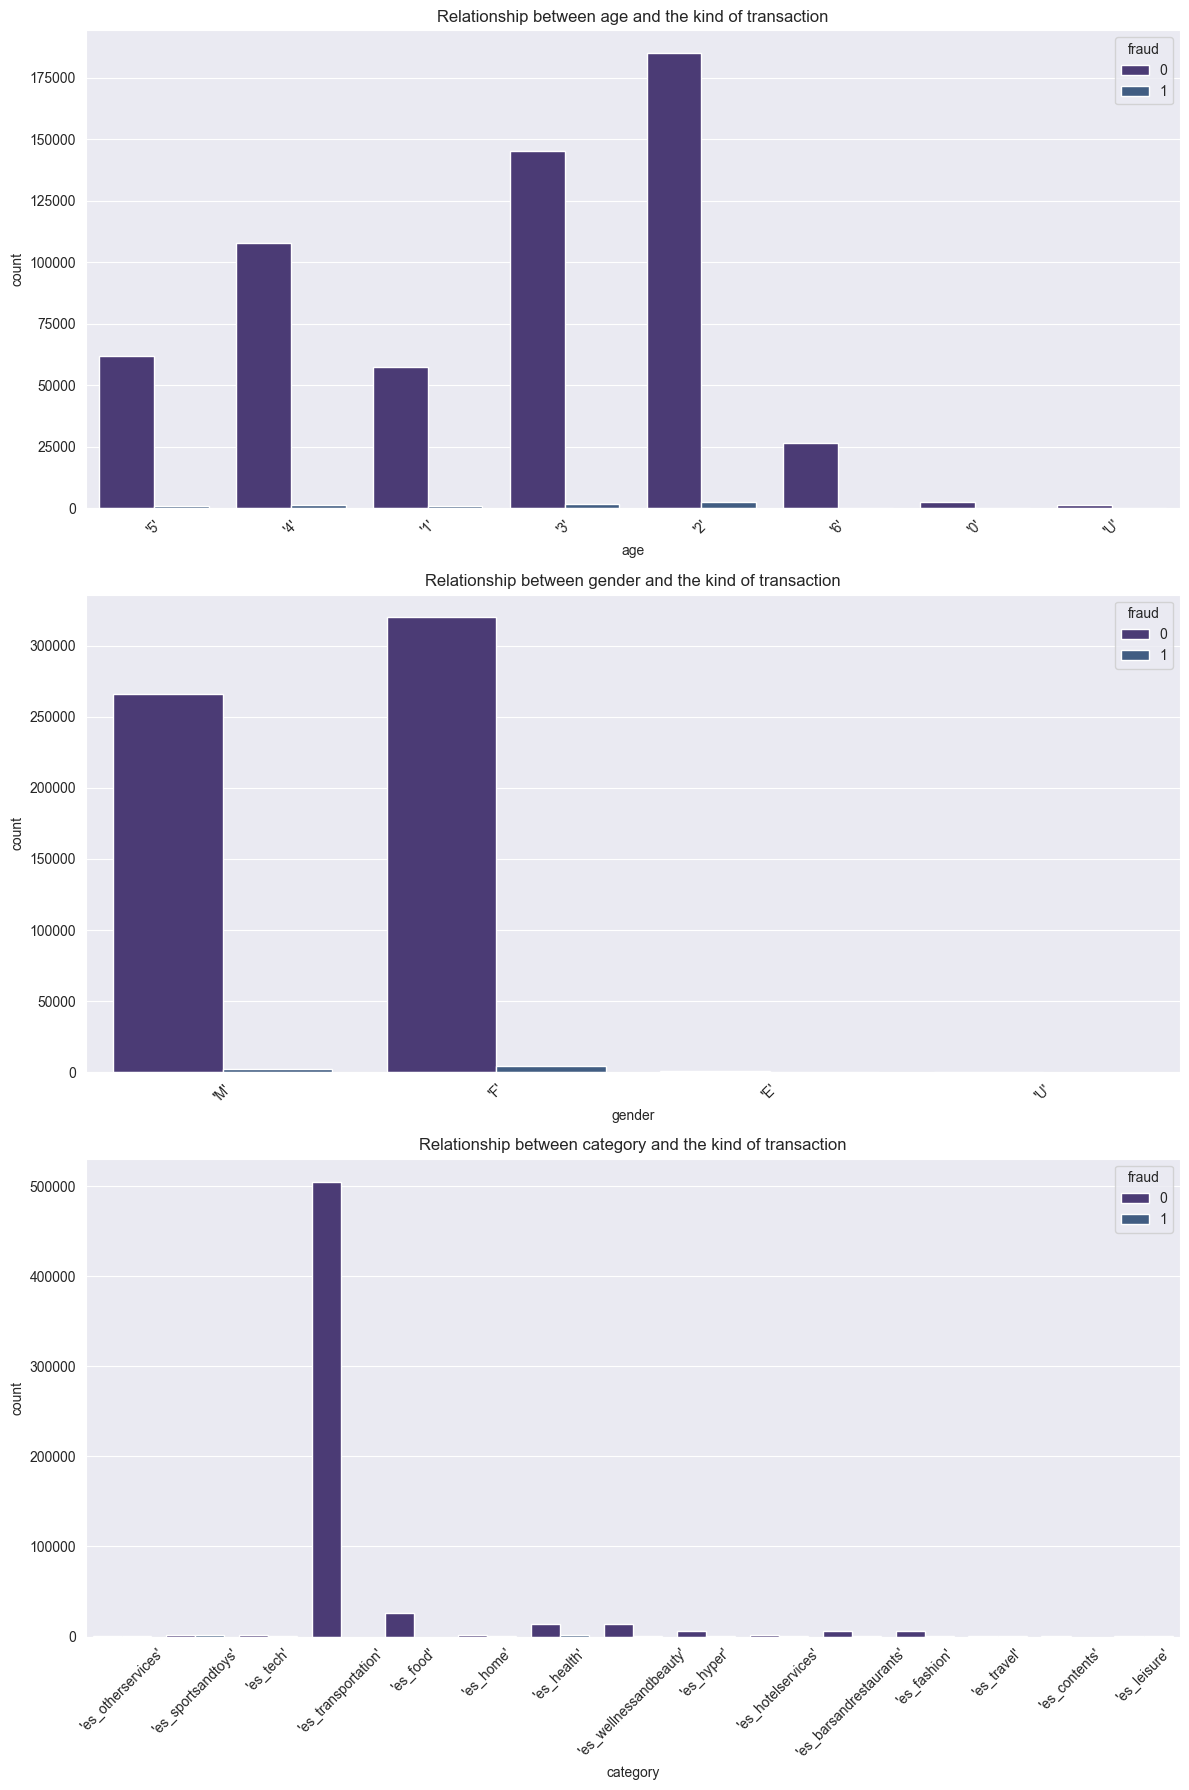

In [37]:
sns.set_style('darkgrid')
sns.set_palette('viridis')
fig = plt.figure(figsize=(12, 18))
c = 1

for col in categorical:
    axis = fig.add_subplot(3, 1, c)
    sns.countplot(x=col, hue='fraud', data=df, ax=axis)
    axis.set_title(f'Relationship between {col} and the kind of transaction')
    # Safer rotation of x-axis labels
    axis.tick_params(axis='x', rotation=45)
    c += 1

plt.tight_layout()


In [38]:
continuous = []
for col in df:
    if col not in categorical:
        continuous.append(col)

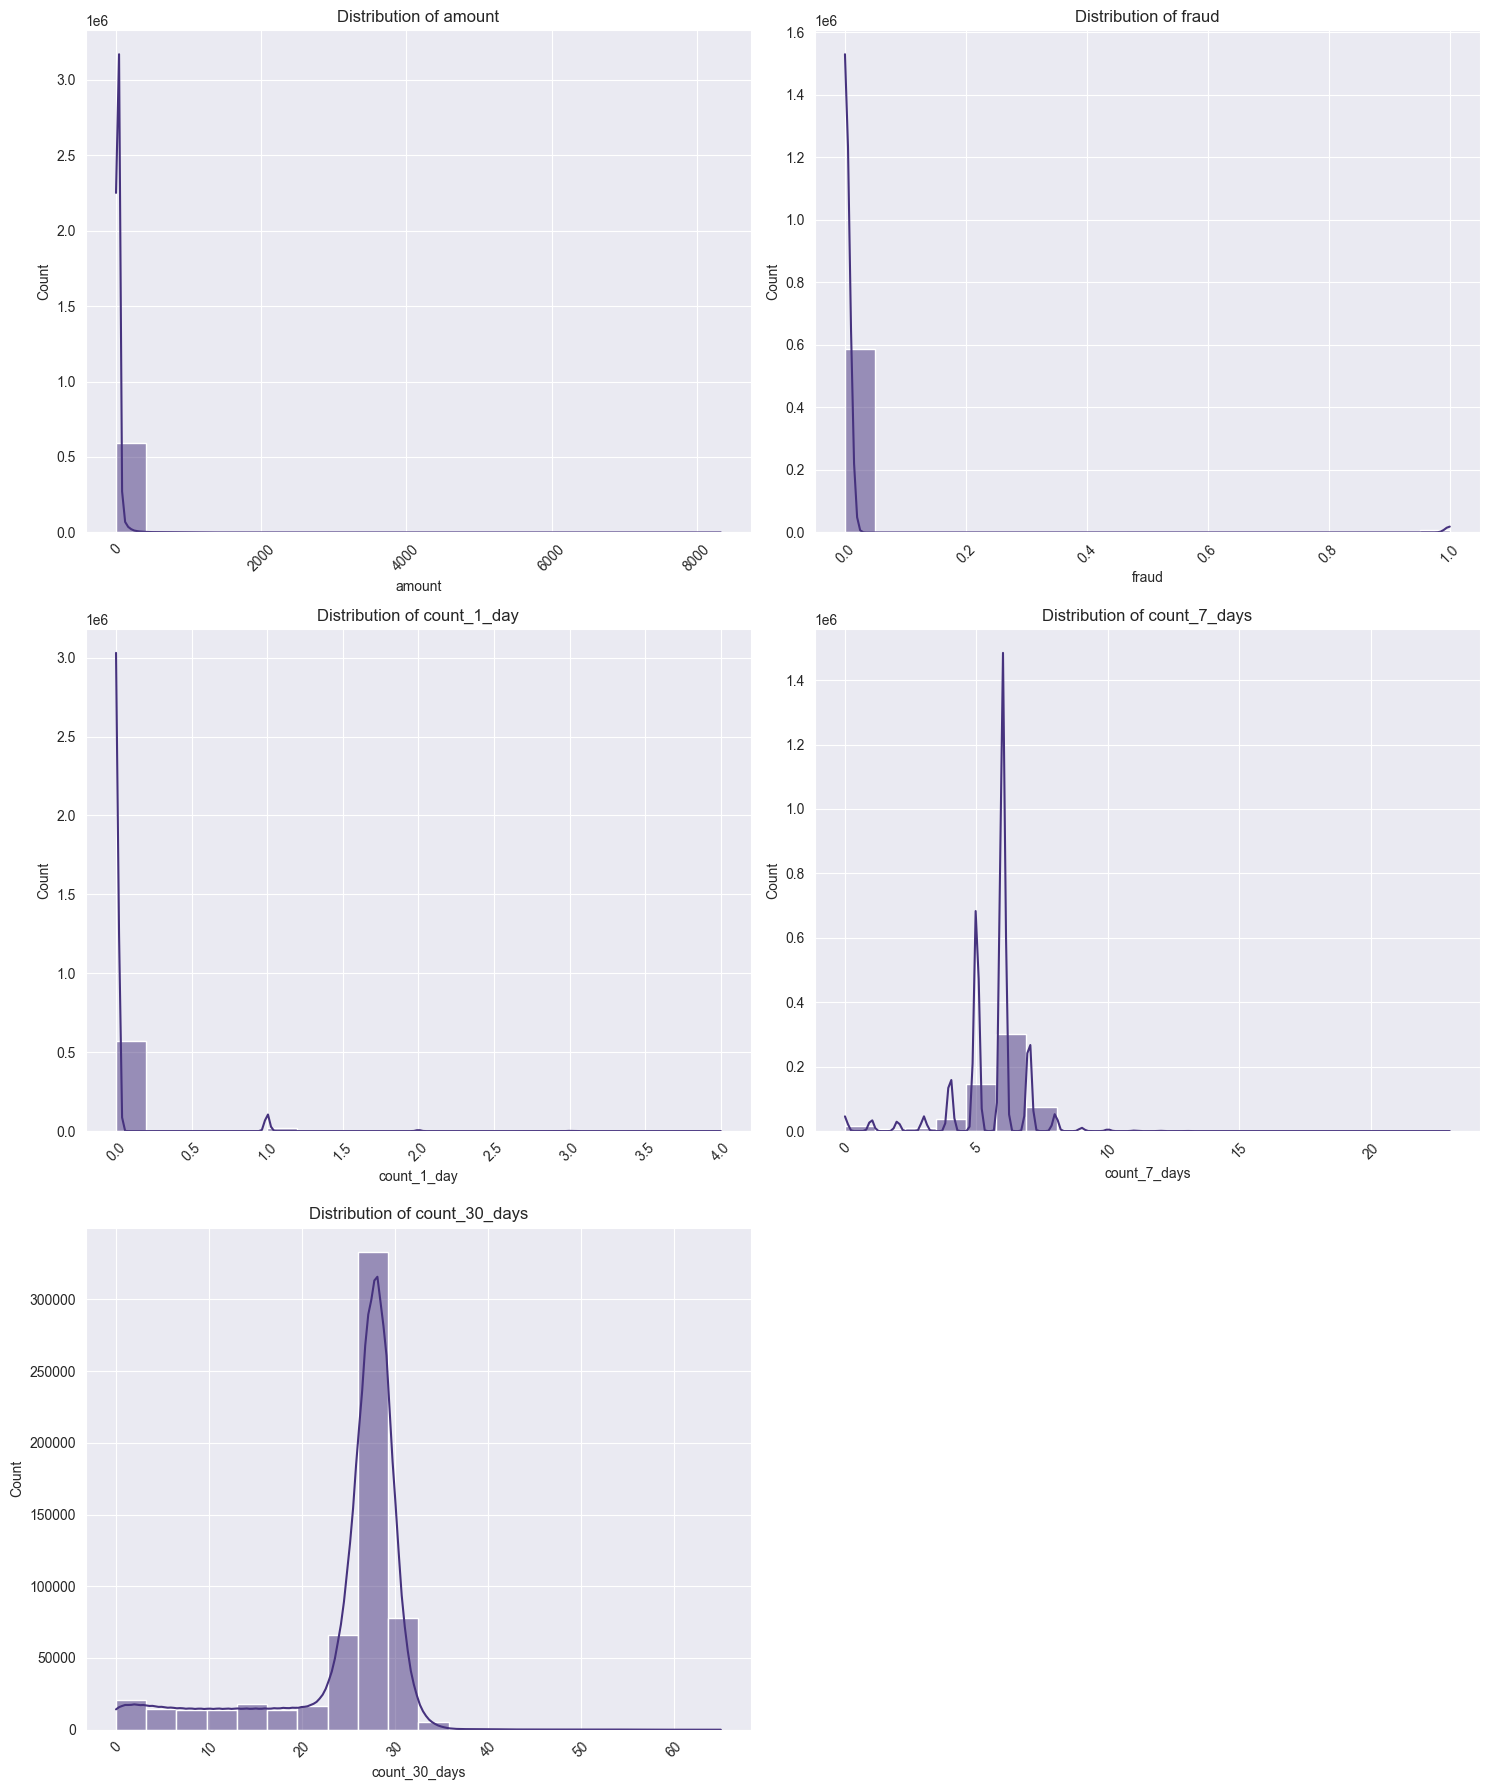

In [39]:
sns.set_style('darkgrid')
fig = plt.figure(figsize=(15, 18))
c = 1

for col in continuous:
    axis = fig.add_subplot(3,2,c)
    sns.histplot(x = col, bins = 20, kde = True, data = df)
    axis.set_title(f'Distribution of {col}')
    # Safer rotation of x-axis labels
    axis.tick_params(axis='x', rotation=45)
    c += 1

plt.tight_layout()


From the plots, all we can confirm is the imbalanced nature of the dataset. Fortunately, models are mathematical and can map relationships dynamically. So let's see how models can work with these attributes and numbers.

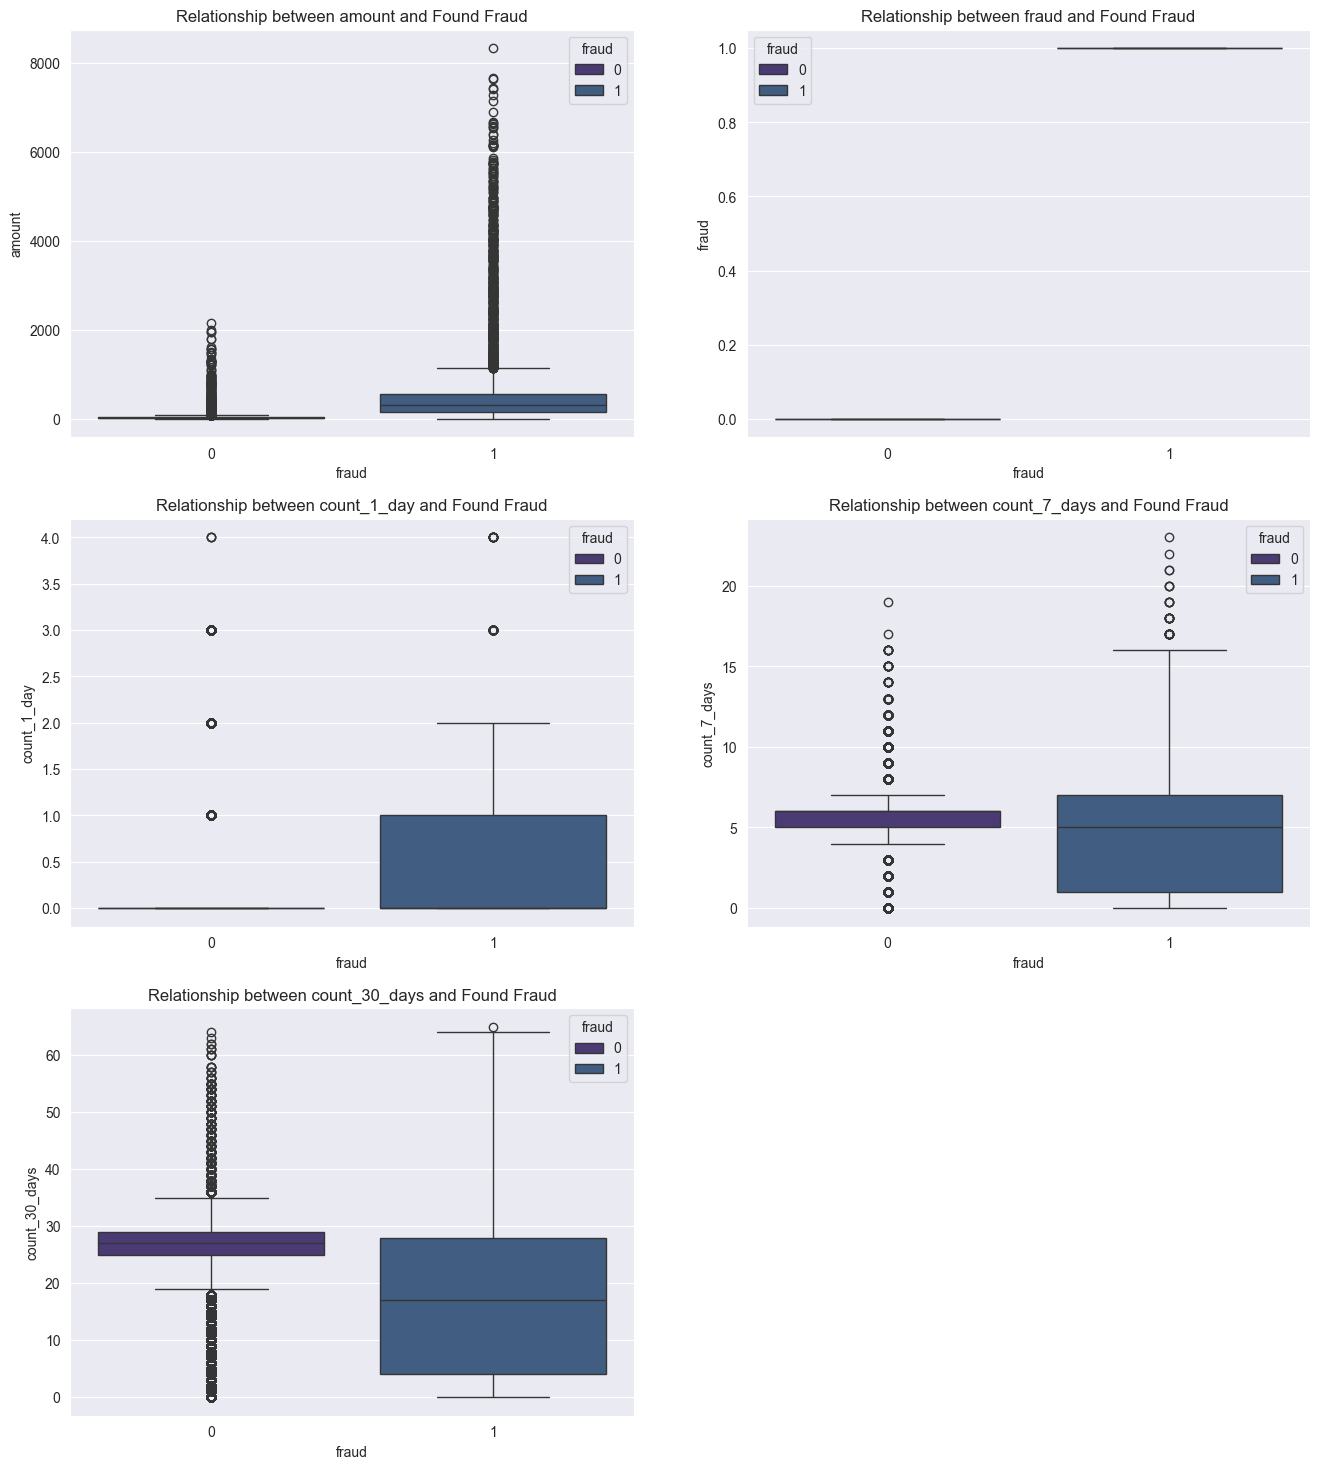

In [40]:
fig = plt.figure(figsize = (16,18))
b = 1
for col in continuous:
    axis = fig.add_subplot(3,2,b)
    sns.boxplot(y = col, x = 'fraud', data = df, hue = 'fraud')
    plt.title(f'Relationship between {col} and Found Fraud')
    b+=1

### Model Training

In [41]:
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import jaccard_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
import optuna
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier 
from catboost import CatBoostClassifier

In [42]:
df

,age,gender,category,amount,fraud,count_1_day,count_7_days,count_30_days
0,'5','M','es_otherservices',143.87,0,0.0,0.0,0.0
1,'5','M','es_sportsandtoys',16.69,0,0.0,0.0,1.0
2,'5','M','es_otherservices',56.18,0,0.0,1.0,2.0
3,'5','M','es_tech',14.74,0,0.0,2.0,3.0
4,'5','M','es_transportation',47.42,0,0.0,3.0,4.0
...,...,...,...,...,...,...,...,...
594638,'2','M','es_transportation',31.94,0,0.0,5.0,26.0
594639,'2','M','es_transportation',1.92,0,0.0,4.0,26.0
594640,'2','M','es_food',62.55,0,0.0,4.0,26.0
594641,'2','M','es_transportation',25.96,0,0.0,4.0,27.0


#### One-Hot Encoding
We must encode our categorical variables into a dummy array via one-hot encoding. These features will be added to our dataframe, and the original features will be dropped to reduce redundancy. 

In [43]:
categorical

['age', 'gender', 'category']

In [44]:
for col in categorical:
    df[col] = df[col].astype(str).str.replace(r"[\"']", "", regex=True)

In [45]:
df

,age,gender,category,amount,fraud,count_1_day,count_7_days,count_30_days
0,5,M,es_otherservices,143.87,0,0.0,0.0,0.0
1,5,M,es_sportsandtoys,16.69,0,0.0,0.0,1.0
2,5,M,es_otherservices,56.18,0,0.0,1.0,2.0
3,5,M,es_tech,14.74,0,0.0,2.0,3.0
4,5,M,es_transportation,47.42,0,0.0,3.0,4.0
...,...,...,...,...,...,...,...,...
594638,2,M,es_transportation,31.94,0,0.0,5.0,26.0
594639,2,M,es_transportation,1.92,0,0.0,4.0,26.0
594640,2,M,es_food,62.55,0,0.0,4.0,26.0
594641,2,M,es_transportation,25.96,0,0.0,4.0,27.0


In [46]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# One-hot encode categorical columns
ohe = OneHotEncoder(sparse_output=False, drop='first')

encoded = ohe.fit_transform(df[categorical])

# Correct column names, accounting for drop='first'
encoded_df = pd.DataFrame(
    encoded,
    columns=[
        f"{col}_{cat}"
        for col, cats in zip(categorical, ohe.categories_)
        for cat in cats[1:]  # Skip first category to match output
    ],
    index=df.index
)

# Final dataset: drop original categoricals, add encoded columns
df = pd.concat([df.drop(columns=categorical), encoded_df], axis=1)


In [47]:
df

,amount,fraud,count_1_day,count_7_days,count_30_days,age_1,age_2,age_3,age_4,age_5,...,category_es_home,category_es_hotelservices,category_es_hyper,category_es_leisure,category_es_otherservices,category_es_sportsandtoys,category_es_tech,category_es_transportation,category_es_travel,category_es_wellnessandbeauty
0,143.87,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,16.69,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,56.18,0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,14.74,0,0.0,2.0,3.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,47.42,0,0.0,3.0,4.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594638,31.94,0,0.0,5.0,26.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
594639,1.92,0,0.0,4.0,26.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
594640,62.55,0,0.0,4.0,26.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
594641,25.96,0,0.0,4.0,27.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Now that has been done, let's split our data into predictors and targets

In [48]:
# splitting the target and predictor variables
X = df.drop('fraud', axis = 1)
Y = df['fraud']

In [49]:
X

,amount,count_1_day,count_7_days,count_30_days,age_1,age_2,age_3,age_4,age_5,age_6,...,category_es_home,category_es_hotelservices,category_es_hyper,category_es_leisure,category_es_otherservices,category_es_sportsandtoys,category_es_tech,category_es_transportation,category_es_travel,category_es_wellnessandbeauty
0,143.87,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,16.69,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,56.18,0.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,14.74,0.0,2.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,47.42,0.0,3.0,4.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594638,31.94,0.0,5.0,26.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
594639,1.92,0.0,4.0,26.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
594640,62.55,0.0,4.0,26.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
594641,25.96,0.0,4.0,27.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [50]:
Y

0         0
1         0
2         0
3         0
4         0
         ..
594638    0
594639    0
594640    0
594641    0
594642    0
Name: fraud, Length: 594643, dtype: int64

In [51]:
# We further split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=10)

In [52]:
# We further split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=10)

In [53]:
x_train.shape, x_test.shape, y_test.shape, y_train.shape

((416250, 28), (178393, 28), (178393,), (416250,))

Now remember our dataset is severely imbalanced, as evidenced below

In [54]:
from collections import Counter

print('The count of each target class(type of transaction), and thier ratios to each other')
print("Train:", Counter(y_train))
print("Test:", Counter(y_test))

The count of each target class(type of transaction), and thier ratios to each other
Train: Counter({0: 411291, 1: 4959})
Test: Counter({0: 176152, 1: 2241})


#### Model Training

Synthetic Minority Oversampling Technique (SMOTE) will be used for oversampling

In [55]:
# importing dependencies
from imblearn.over_sampling import ADASYN
from imblearn.over_sampling import SMOTE

#### Logistic Regression

In [1]:
# Optuna Objective with SMOTE
def objective_smote(trial):
    try:
        C = trial.suggest_float('model__C', 0.01, 100, log=True)
        penalty = trial.suggest_categorical('model__penalty', ['l1', 'l2'])
        class_weight = trial.suggest_categorical('model__class_weight', [None, 'balanced'])
        k_neighbors = trial.suggest_int('smote__k_neighbors', 3, 10)

        pipe = Pipeline([
            ('smote', SMOTE(random_state = 42, k_neighbors = k_neighbors, sampling_strategy=0.8)),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                C=C,
                penalty=penalty,
                class_weight=class_weight,
                solver='liblinear',
                max_iter=1000
            ))
        ])

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        score = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1, error_score='raise')
        
        return score.mean()

    except Exception as e:
        print(f'Trial failed: {e}')
        raise optuna.exceptions.TrialPruned()

# Run SMOTE Optimization
study_smote = optuna.create_study(direction='maximize')
study_smote.optimize(objective_smote, n_trials=15)

print("\n=== SMOTE Optimization Results ===")
print("Best AUC Score:", study_smote.best_value)
print("Best Parameters:", study_smote.best_params)


NameError: name 'optuna' is not defined

In [57]:
### training the final model on the best parameters
# Extract and clean best params from SMOTE study
best_params = study_smote.best_params.copy()

# Remove the pipeline step prefixes
cleaned_params = {key.replace('model__', ''): value for key, value in best_params.items() if key.startswith('model__')}
k_neighbors = best_params.get('smote__k_neighbors', 5)

# Build pipeline for final training & prediction
pipe_lgr = Pipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=k_neighbors, sampling_strategy=0.8)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(**cleaned_params,solver='liblinear', random_state=42, max_iter=1000))
])

# Train on full training set
pipe_lgr.fit(x_train, y_train)

# Predict on test set
pred_lgr = pipe_lgr.predict(x_test)

#### XGBoost

In [58]:
# Optuna Objective with SMOTE and XGBoost
def objective_smote_xgb(trial):
    try:
        k_neighbors = trial.suggest_int('smote__k_neighbors', 3, 10)

        # XGBoost hyperparameters
        n_estimators = trial.suggest_int('xgb__n_estimators', 100, 500)
        max_depth = trial.suggest_int('xgb__max_depth', 3, 15)
        learning_rate = trial.suggest_float('xgb__learning_rate', 0.01, 0.3, log=True)
        subsample = trial.suggest_float('xgb__subsample', 0.5, 1.0)
        colsample_bytree = trial.suggest_float('xgb__colsample_bytree', 0.5, 1.0)
        scale_pos_weight = trial.suggest_float('xgb__scale_pos_weight', 1, 10)  # Helpful for imbalanced data

        pipe = Pipeline([
            ('smote', SMOTE(random_state=42, k_neighbors=k_neighbors, sampling_strategy=0.8)),
            ('scaler', StandardScaler()),
            ('xgb', XGBClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                learning_rate=learning_rate,
                subsample=subsample,
                colsample_bytree=colsample_bytree,
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                use_label_encoder=False,
                eval_metric='logloss'
            ))
        ])

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        score = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1, error_score='raise')

        return score.mean()

    except Exception as e:
        print(f'Trial failed: {e}')
        raise optuna.exceptions.TrialPruned()

# Run SMOTE Optimization for XGBoost
study_smote_xgb = optuna.create_study(direction='maximize')
study_smote_xgb.optimize(objective_smote_xgb, n_trials=15)

print("\n=== SMOTE + XGBoost Optimization Results ===")
print("Best AUC Score:", study_smote_xgb.best_value)
print("Best Parameters:", study_smote_xgb.best_params)

[I 2025-11-08 09:24:55,628] A new study created in memory with name: no-name-f9534ee1-5d88-4afd-a438-57625b1895cd
[I 2025-11-08 09:27:12,941] Trial 0 finished with value: 0.9950777756226451 and parameters: {'smote__k_neighbors': 6, 'xgb__n_estimators': 238, 'xgb__max_depth': 12, 'xgb__learning_rate': 0.024102564128655524, 'xgb__subsample': 0.5351128928864225, 'xgb__colsample_bytree': 0.6606442978053877, 'xgb__scale_pos_weight': 9.359014685740767}. Best is trial 0 with value: 0.9950777756226451.
[I 2025-11-08 09:29:54,965] Trial 1 finished with value: 0.9950666380807744 and parameters: {'smote__k_neighbors': 5, 'xgb__n_estimators': 325, 'xgb__max_depth': 14, 'xgb__learning_rate': 0.012614305668658152, 'xgb__subsample': 0.9218084839447043, 'xgb__colsample_bytree': 0.6427380337505575, 'xgb__scale_pos_weight': 6.677486754161868}. Best is trial 0 with value: 0.9950777756226451.
[I 2025-11-08 09:30:36,741] Trial 2 finished with value: 0.9948376994605412 and parameters: {'smote__k_neighbors':


=== SMOTE + XGBoost Optimization Results ===
Best AUC Score: 0.9953111657310905
Best Parameters: {'smote__k_neighbors': 10, 'xgb__n_estimators': 351, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.08708603831092995, 'xgb__subsample': 0.9322577779267502, 'xgb__colsample_bytree': 0.8209190956915619, 'xgb__scale_pos_weight': 7.419039833847219}


In [59]:
### Final training for XGBoost with SMOTE

# Extract best params
best_params = study_smote_xgb.best_params.copy()

# Clean out pipeline prefixes
cleaned_params = {key.replace('xgb__', ''): value for key, value in best_params.items() if key.startswith('xgb__')}
k_neighbors = best_params.get('smote__k_neighbors', 5)

# Build final pipeline
pipe_xgb = Pipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=k_neighbors, sampling_strategy=0.8)),
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(
        **cleaned_params,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

# Train on full training set
pipe_xgb.fit(x_train, y_train)

# Predict on test set
pred_xgb = pipe_xgb.predict(x_test)


C:\Users\Nonso\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [09:47:54] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


#### Catboost

In [60]:
from catboost import CatBoostClassifier

def objective_smote_catboost(trial):
    try:
        k_neighbors = trial.suggest_int('smote__k_neighbors', 3, 10)
        
        # CatBoost hyperparameters
        iterations = trial.suggest_int('cat__iterations', 100, 500)
        depth = trial.suggest_int('cat__depth', 3, 10)
        learning_rate = trial.suggest_float('cat__learning_rate', 0.01, 0.3, log=True)
        l2_leaf_reg = trial.suggest_float('cat__l2_leaf_reg', 1.0, 10.0)
        
        pipe = Pipeline([
            ('smote', SMOTE(random_state=42, k_neighbors=k_neighbors, sampling_strategy=0.8)),
            ('scaler', StandardScaler()),  # Optional with CatBoost, but safe to leave
            ('cat', CatBoostClassifier(
                iterations=iterations,
                depth=depth,
                learning_rate=learning_rate,
                l2_leaf_reg=l2_leaf_reg,
                verbose=0,
                random_state=42
            ))
        ])
        
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        score = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1, error_score='raise')
        
        return score.mean()

    except Exception as e:
        print(f'Trial failed: {e}')
        raise optuna.exceptions.TrialPruned()

# Run SMOTE Optimization for CatBoost
study_smote_cat = optuna.create_study(direction='maximize')
study_smote_cat.optimize(objective_smote_catboost, n_trials=15)

print("\n=== SMOTE + CatBoost Optimization Results ===")
print("Best AUC Score:", study_smote_cat.best_value)
print("Best Parameters:", study_smote_cat.best_params)


[I 2025-11-08 09:48:14,194] A new study created in memory with name: no-name-6ef52bc8-e6b8-4c92-b768-6db90a09a1df
[I 2025-11-08 09:49:18,972] Trial 0 finished with value: 0.9946637970555333 and parameters: {'smote__k_neighbors': 4, 'cat__iterations': 140, 'cat__depth': 7, 'cat__learning_rate': 0.026465585726244276, 'cat__l2_leaf_reg': 2.2194832691081765}. Best is trial 0 with value: 0.9946637970555333.
[I 2025-11-08 09:51:28,696] Trial 1 finished with value: 0.995019268411288 and parameters: {'smote__k_neighbors': 9, 'cat__iterations': 252, 'cat__depth': 8, 'cat__learning_rate': 0.02663765943572131, 'cat__l2_leaf_reg': 9.435352977204959}. Best is trial 1 with value: 0.995019268411288.
[I 2025-11-08 09:53:19,057] Trial 2 finished with value: 0.9946089180396186 and parameters: {'smote__k_neighbors': 6, 'cat__iterations': 225, 'cat__depth': 7, 'cat__learning_rate': 0.01659313792582759, 'cat__l2_leaf_reg': 3.8052402962513727}. Best is trial 1 with value: 0.995019268411288.
[I 2025-11-08 09


=== SMOTE + CatBoost Optimization Results ===
Best AUC Score: 0.995220952968268
Best Parameters: {'smote__k_neighbors': 7, 'cat__iterations': 483, 'cat__depth': 5, 'cat__learning_rate': 0.1001004978967808, 'cat__l2_leaf_reg': 7.403402414355632}


In [61]:
# Extract best params
best_params = study_smote_cat.best_params.copy()

# Clean out pipeline prefixes
cleaned_params = {key.replace('cat__', ''): value for key, value in best_params.items() if key.startswith('cat__')}
k_neighbors = best_params.get('smote__k_neighbors', 5)

# Build final pipeline
pipe_cat = Pipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=k_neighbors, sampling_strategy=0.8)),
    ('scaler', StandardScaler()),
    ('cat', CatBoostClassifier(
        **cleaned_params,
        verbose=0,
        random_state=42
    ))
])

# Train on full training set
pipe_cat.fit(x_train, y_train)

# Predict on test set
pred_cat = pipe_cat.predict(x_test)


#### LightGBM

In [62]:
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

def objective_smote_lgb(trial):
    try:
        k_neighbors = trial.suggest_int('smote__k_neighbors', 3, 10)

        # LightGBM hyperparameters
        n_estimators = trial.suggest_int('lgb__n_estimators', 100, 500)
        num_leaves = trial.suggest_int('lgb__num_leaves', 15, 100)
        learning_rate = trial.suggest_float('lgb__learning_rate', 0.01, 0.3, log=True)
        subsample = trial.suggest_float('lgb__subsample', 0.5, 1.0)
        colsample_bytree = trial.suggest_float('lgb__colsample_bytree', 0.5, 1.0)
        reg_alpha = trial.suggest_float('lgb__reg_alpha', 0.0, 5.0)
        reg_lambda = trial.suggest_float('lgb__reg_lambda', 0.0, 5.0)

        pipe = Pipeline([
            ('smote', SMOTE(random_state=42, k_neighbors=k_neighbors, sampling_strategy=0.8)),
            ('scaler', StandardScaler()),  # Optional but consistent
            ('lgb', lgb.LGBMClassifier(
                n_estimators=n_estimators,
                num_leaves=num_leaves,
                learning_rate=learning_rate,
                subsample=subsample,
                colsample_bytree=colsample_bytree,
                reg_alpha=reg_alpha,
                reg_lambda=reg_lambda,
                random_state=42,
                n_jobs=-1
            ))
        ])

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        score = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1, error_score='raise')

        return score.mean()

    except Exception as e:
        print(f'Trial failed: {e}')
        raise optuna.exceptions.TrialPruned()

# Run Optimization
study_smote_lgb = optuna.create_study(direction='maximize')
study_smote_lgb.optimize(objective_smote_lgb, n_trials=15)

print("\n=== SMOTE + LightGBM Optimization Results ===")
print("Best AUC Score:", study_smote_lgb.best_value)
print("Best Parameters:", study_smote_lgb.best_params)


[I 2025-11-08 10:28:57,202] A new study created in memory with name: no-name-12709136-bfe7-4e0b-b3d3-01f90352e756
[I 2025-11-08 10:29:53,016] Trial 0 finished with value: 0.9952963898964 and parameters: {'smote__k_neighbors': 8, 'lgb__n_estimators': 399, 'lgb__num_leaves': 27, 'lgb__learning_rate': 0.1644532357691685, 'lgb__subsample': 0.6166957355670608, 'lgb__colsample_bytree': 0.6560827128832067, 'lgb__reg_alpha': 0.5735158678851993, 'lgb__reg_lambda': 4.07848619701797}. Best is trial 0 with value: 0.9952963898964.
[I 2025-11-08 10:31:00,667] Trial 1 finished with value: 0.9955342481840285 and parameters: {'smote__k_neighbors': 8, 'lgb__n_estimators': 410, 'lgb__num_leaves': 62, 'lgb__learning_rate': 0.028597925371966544, 'lgb__subsample': 0.7345645074992719, 'lgb__colsample_bytree': 0.8655643927176204, 'lgb__reg_alpha': 0.6783612217480112, 'lgb__reg_lambda': 1.302368189910696}. Best is trial 1 with value: 0.9955342481840285.
[I 2025-11-08 10:31:44,177] Trial 2 finished with value: 


=== SMOTE + LightGBM Optimization Results ===
Best AUC Score: 0.9955342481840285
Best Parameters: {'smote__k_neighbors': 8, 'lgb__n_estimators': 410, 'lgb__num_leaves': 62, 'lgb__learning_rate': 0.028597925371966544, 'lgb__subsample': 0.7345645074992719, 'lgb__colsample_bytree': 0.8655643927176204, 'lgb__reg_alpha': 0.6783612217480112, 'lgb__reg_lambda': 1.302368189910696}


In [63]:
# Extract best params
best_params = study_smote_lgb.best_params.copy()

# Clean out pipeline prefixes
cleaned_params = {key.replace('lgb__', ''): value for key, value in best_params.items() if key.startswith('lgb__')}
k_neighbors = best_params.get('smote__k_neighbors', 5)

# Build final pipeline
pipe_lgb = Pipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=k_neighbors, sampling_strategy=0.8)),
    ('scaler', StandardScaler()),
    ('lgb', lgb.LGBMClassifier(
        **cleaned_params,
        random_state=42,
        n_jobs=-1
    ))
])

# Train on full training set
pipe_lgb.fit(x_train, y_train)

# Predict on test set
pred_lgb = pipe_lgb.predict(x_test)


[LightGBM] [Info] Number of positive: 329032, number of negative: 411291
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.078432 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5939
[LightGBM] [Info] Number of data points in the train set: 740323, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.444444 -> initscore=-0.223146
[LightGBM] [Info] Start training from score -0.223146


### Model Evaluation

In [69]:
from sklearn.metrics import accuracy_score, roc_auc_score, jaccard_score, f1_score, precision_score, recall_score

model_scores = {
    "Logistic Regression (SMOTE)": {
        "Accuracy": accuracy_score(y_test, pred_lgr),
        "ROC-AUC": study_smote.best_value,
        "F1-score": f1_score(y_test, pred_lgr, average='macro'),
        "Precision": precision_score(y_test, pred_lgr, average='macro'),
        "Recall": recall_score(y_test, pred_lgr, average='macro')
    },
    
    "XGBoost (SMOTE)": {
        "Accuracy": accuracy_score(y_test, pred_xgb),
        "ROC-AUC": study_smote_xgb.best_value,
        "F1-score": f1_score(y_test, pred_xgb, average='macro'),
        "Precision": precision_score(y_test, pred_xgb, average='macro'),
        "Recall": recall_score(y_test, pred_xgb, average='macro')
    },
    
    "LightGBM (SMOTE)": {
        "Accuracy": accuracy_score(y_test, pred_lgb),
        "ROC-AUC": study_smote_lgb.best_value,
        "F1-score": f1_score(y_test, pred_lgb, average='macro'),
        "Precision": precision_score(y_test, pred_lgb, average='macro'),
        "Recall": recall_score(y_test, pred_lgb, average='macro')
    },
    
    "CatBoost (SMOTE)": {
        "Accuracy": accuracy_score(y_test, pred_cat),
        "ROC-AUC": study_smote_cat.best_value,
        "F1-score": f1_score(y_test, pred_cat, average='macro'),
        "Precision": precision_score(y_test, pred_cat, average='macro'),
        "Recall": recall_score(y_test, pred_cat, average='macro')
    }
}

# Optional: quick DataFrame view
import pandas as pd
model_scores_df = pd.DataFrame(model_scores).T
display(model_scores_df)


,Accuracy,ROC-AUC,F1-score,Precision,Recall
Logistic Regression (SMOTE),0.950575,0.992925,0.651337,0.598724,0.956030
XGBoost (SMOTE),0.985919,0.995311,0.803362,0.733414,0.939122
LightGBM (SMOTE),0.995033,0.995534,0.890006,0.932974,0.854966
CatBoost (SMOTE),0.994748,0.995221,0.887415,0.913770,0.864294


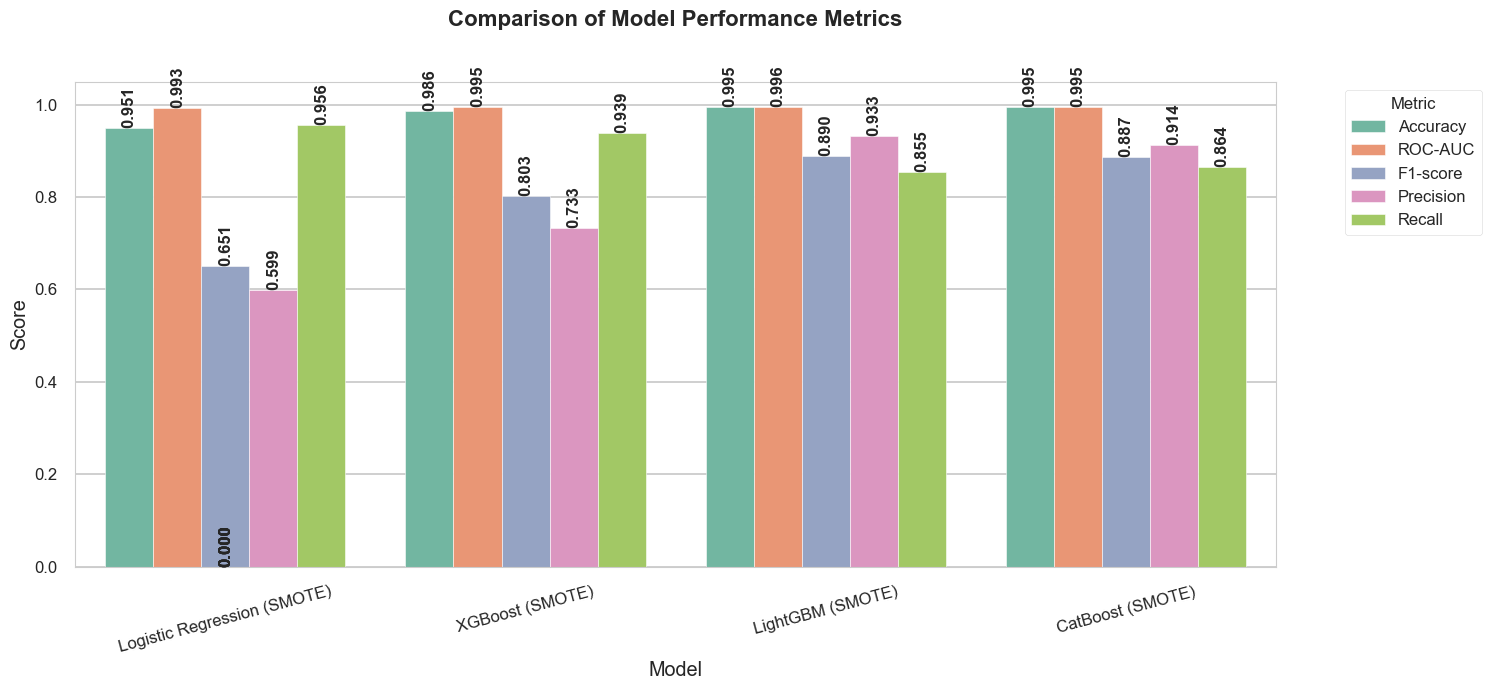

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data
data = {
    "Model": ["Logistic Regression (SMOTE)", "XGBoost (SMOTE)", "LightGBM (SMOTE)", "CatBoost (SMOTE)"],
    "Accuracy": [0.950575, 0.985919, 0.995033, 0.994748],
    "ROC-AUC": [0.992925, 0.995311, 0.995534, 0.995221],
    "F1-score": [0.651337, 0.803362, 0.890006, 0.887415],
    "Precision": [0.598724, 0.733414, 0.932974, 0.913770],
    "Recall": [0.956030, 0.939122, 0.854966, 0.864294]
}

df = pd.DataFrame(data)

# Melt the DataFrame for Seaborn
df_melt = df.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Plot
plt.figure(figsize=(15,7))
sns.set_style("whitegrid")
barplot = sns.barplot(data=df_melt, x="Model", y="Score", hue="Metric", palette="Set2")

# Annotate bars with bigger text
for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(f'{height:.3f}', 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha='center', va='bottom', 
                     fontsize=12, rotation=90, fontweight='bold')

plt.title("Comparison of Model Performance Metrics", fontsize=16, fontweight='bold', pad = '40')
plt.ylim(0, 1.05)
plt.xticks(rotation=15, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=12)
plt.tight_layout()
plt.show()


The models perform really well.

#### Precision Recall Curve(PRC)

A PRC is an evaluation technique that evaluates a model's performance by striking a balance between `Precision & Recall`, two very important evaluation metrics, especially in the context of fraud detection.

> Precision is the measure of the proportion of correctly predicted positives - `TP/(TP +FP)`

> Recall is the measure of the proportion of how many positives were captured. How is this not the same as precision? It's the measure of how many positives were actually caught by the model. `TP/(TP+FN)`.

Recall is generally more important in context because recall flags how many positive classes(frauds) that did not go unnoticed, thereby reducing false negatives. But a balance between the two is very essential, as in also trying to capture all fraud instances, you should be careful in trying to make sure legitimate transactions are not flagged as frauds. In other words, minimize false positives. That is exactly where precision comes in.


#### Why is an AU-PRC more important than an ROC-AUC in this context?
In real-world transactions, illegitimate transactions are always of lower proportions to lower ones in a sample demographic. In our dataset, only 7200 transactions were fraudulent out of over 590k... and this was synthetically generated to guide model training, so the proportions might even be more balanced than in the real world.

Because of this imbalanced nature, we cannot generally focus on just predicting classes accurately, as any model can predict most of the classes as 0(legitimate in this case), and get an escalated score. The minority class has to be taken into account.

`ROC-AUC` treats all classes as equal, and that is not the most optimal evaluation style in this context. `PRC Focuses Only on the Positive Class (Fraud)`

PRC evaluates 
- Precision = "Of predicted frauds, how many were actual frauds?"
- Recall = "Of all actual frauds, how many did we catch?"

Therefore, a higher AU-PRC is a guarantee of a more realistic and generalized performance in the real world.

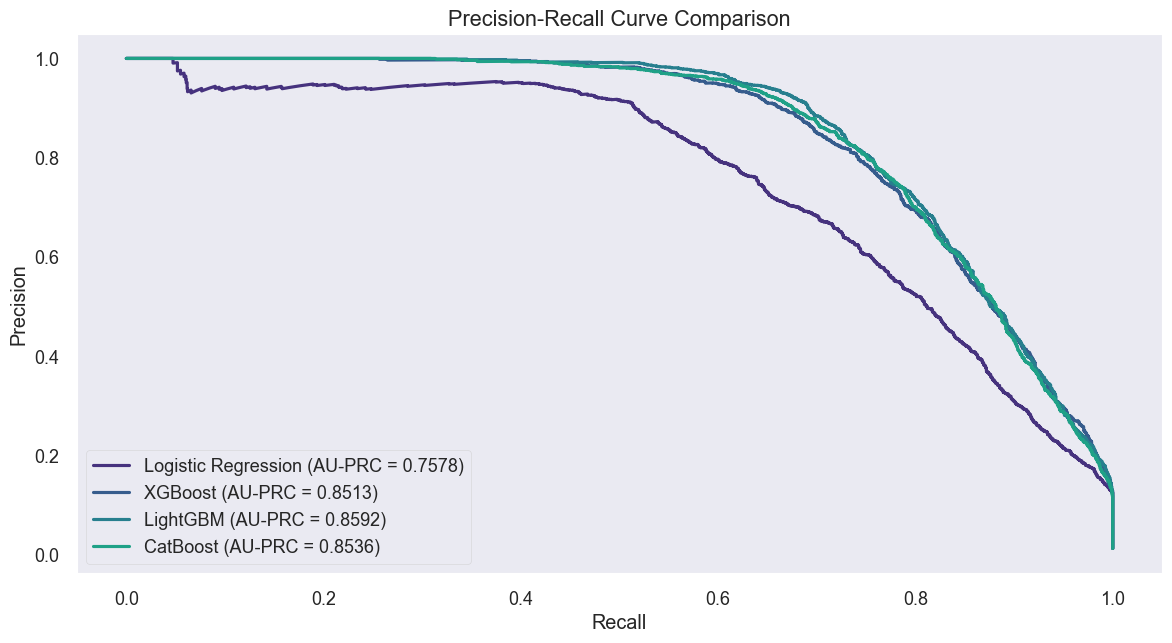

In [66]:
from sklearn.metrics import precision_recall_curve, auc, average_precision_score
models = {
    "Logistic Regression": (pipe_lgr, pred_lgr),
    "XGBoost": (pipe_xgb, pred_xgb),
    "LightGBM": (pipe_lgb, pred_lgb),
    "CatBoost": (pipe_cat, pred_cat)
}

plt.figure(figsize=(14,7))

for name, (model, preds) in models.items():
    y_probs = model.predict_proba(x_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    prc_auc = auc(recall, precision)
    
    plt.plot(recall, precision, label=f"{name} (AU-PRC = {prc_auc:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.grid()
plt.legend()
plt.show()


#### Interpretation of AU-PRC
- Tree-Based Models (XGBoost, LightGBM, CatBoost) outperform Logistic Regression significantly
- Their curves hug the top-right corner better, meaning:
> ✔ High precision at varying recall levels
> 
> ✔ More reliable fraud detection with fewer false alarms
- LightGBM marginally edges out others in AU-PRC, but all three gradient boosting models are very competitive
- Logistic Regression, while decent, struggles to maintain both high precision and recall, typical for linear models on complex, imbalanced tasks

On the above plot, you can see the trends and variance in thresholds of precision and recall. 
Depending on business needs:
- If false negatives are unacceptable (missing fraud costs a lot), lean towards a lower threshold to boost recall
- If false positives severely inconvenience users (customer friction), use a higher threshold to boost precision

Typically for fraud:
- Aim for a threshold where recall is high (≥ 85%) without sacrificing precision below practical limits (~80% if possible)
- Ideal balance often falls between thresholds 0.3 to 0.5, but always plot curves to decid

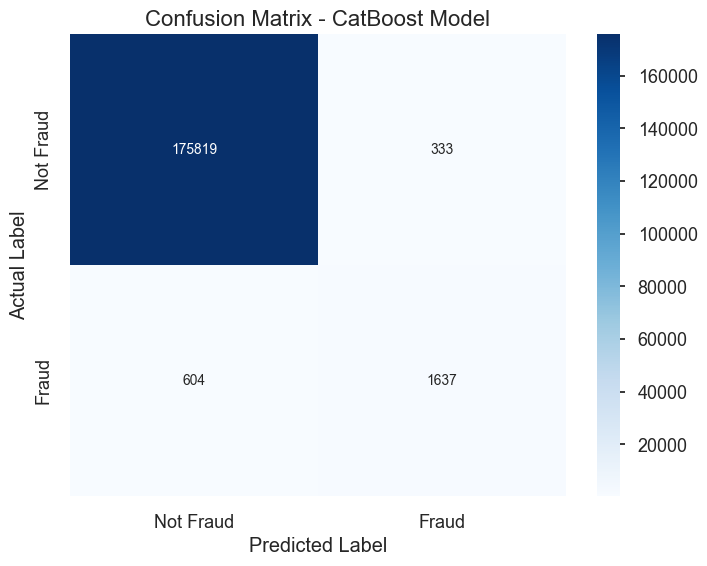


Classification Report - CatBoost Model
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    176152
       Fraud       0.83      0.73      0.78      2241

    accuracy                           0.99    178393
   macro avg       0.91      0.86      0.89    178393
weighted avg       0.99      0.99      0.99    178393


Model Accuracy and Confidence Interval
Accuracy: 0.9947
95% Confidence Interval: [0.9944 - 0.9951]


In [81]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import resample

# --- 1. Generate and Visualize the Confusion Matrix for the XGBoost Model ---

# Calculate the confusion matrix
cm = confusion_matrix(y_test, pred_cat)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix - CatBoost Model', fontsize=16)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


# --- 2. Print a Detailed Classification Report ---
# This report includes precision, recall, and F1-score, which are crucial for fraud detection
print("\n" + "="*50)
print("Classification Report - CatBoost Model")
print("="*50)
print(classification_report(y_test, pred_cat, target_names=['Not Fraud', 'Fraud']))


# --- 3. Calculate and Print the 95% Confidence Interval for Accuracy ---
# We will use the bootstrapping method to calculate the confidence interval

def get_accuracy_ci(y_true, y_pred, n_bootstraps=1000):
    """Calculates the 95% confidence interval for accuracy using bootstrapping."""
    rng_seed = 42  # for reproducibility
    rng = np.random.RandomState(rng_seed)
    
    bootstrapped_scores = []
    
    for i in range(n_bootstraps):
        # Create a bootstrap sample by sampling with replacement
        indices = rng.randint(0, len(y_pred), len(y_pred))
        
        # We can't use accuracy_score if a class is missing in the sample
        if len(np.unique(y_true[indices])) < 2:
            continue
            
        score = accuracy_score(y_true[indices], y_pred[indices])
        bootstrapped_scores.append(score)
        
    # Calculate the 95% confidence interval
    alpha = 0.95
    lower_bound = np.percentile(bootstrapped_scores, (1 - alpha) / 2 * 100)
    upper_bound = np.percentile(bootstrapped_scores, (alpha + (1 - alpha) / 2) * 100)
    
    return lower_bound, upper_bound

# Calculate and print the CI for the XGBoost model's accuracy
accuracy = accuracy_score(y_test, pred_cat)
lower, upper = get_accuracy_ci(y_test.values, pred_cat)

print("\n" + "="*50)
print("Model Accuracy and Confidence Interval")
print("="*50)
print(f"Accuracy: {accuracy:.4f}")
print(f"95% Confidence Interval: [{lower:.4f} - {upper:.4f}]")
print("="*50)

### Model Explainability with SHAP
Fraud detection models, especially in financial services, must be interpretable to ensure trust, fairness, and regulatory compliance. While predictive performance is crucial, understanding why a model flags a transaction as fraudulent is equally important.

`SHAP (SHapley Additive exPlanations)` offers both global and local interpretability based on cooperative game theory. It assigns a contribution score to each feature, indicating how much it influenced a prediction.

This section visualizes feature impacts across all our trained models.


Explaining XGBoost

🌟 Global Feature Importance - XGBoost (Sampled 500 rows)


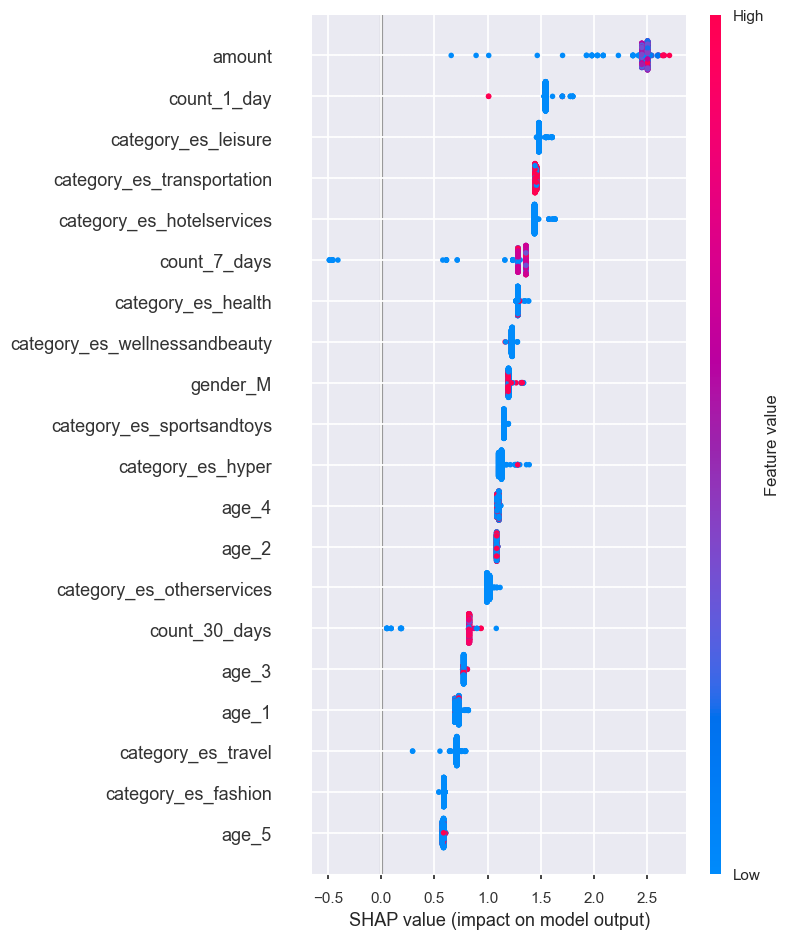


Explaining LightGBM

🌟 Global Feature Importance - LightGBM (Sampled 500 rows)


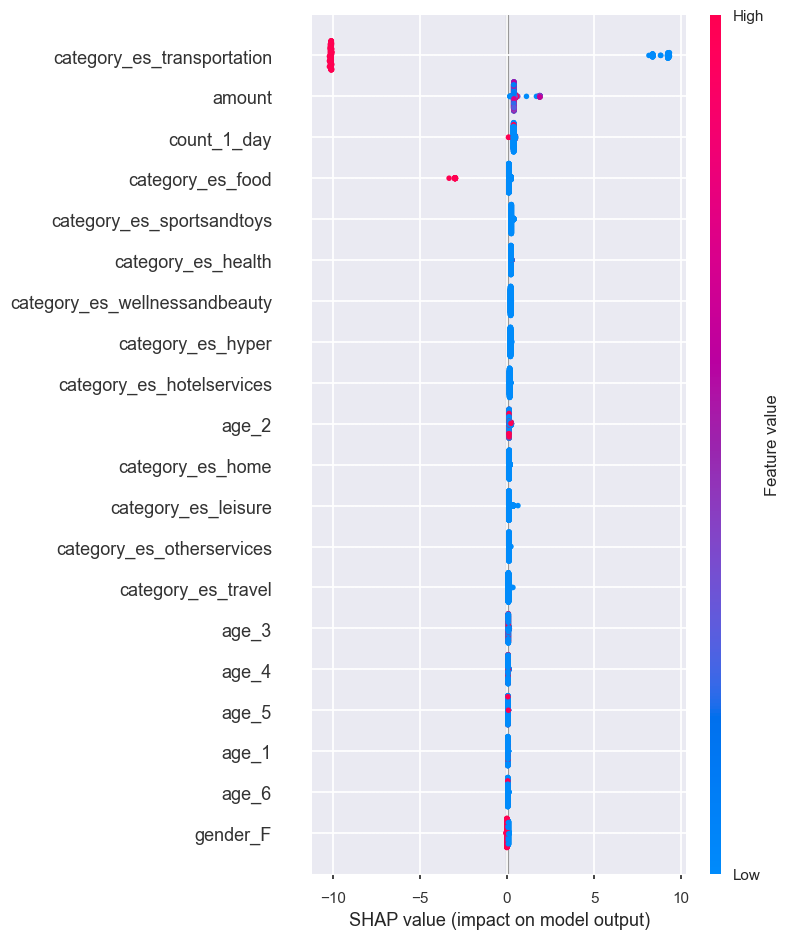


Explaining CatBoost

🌟 Global Feature Importance - CatBoost (Sampled 500 rows)


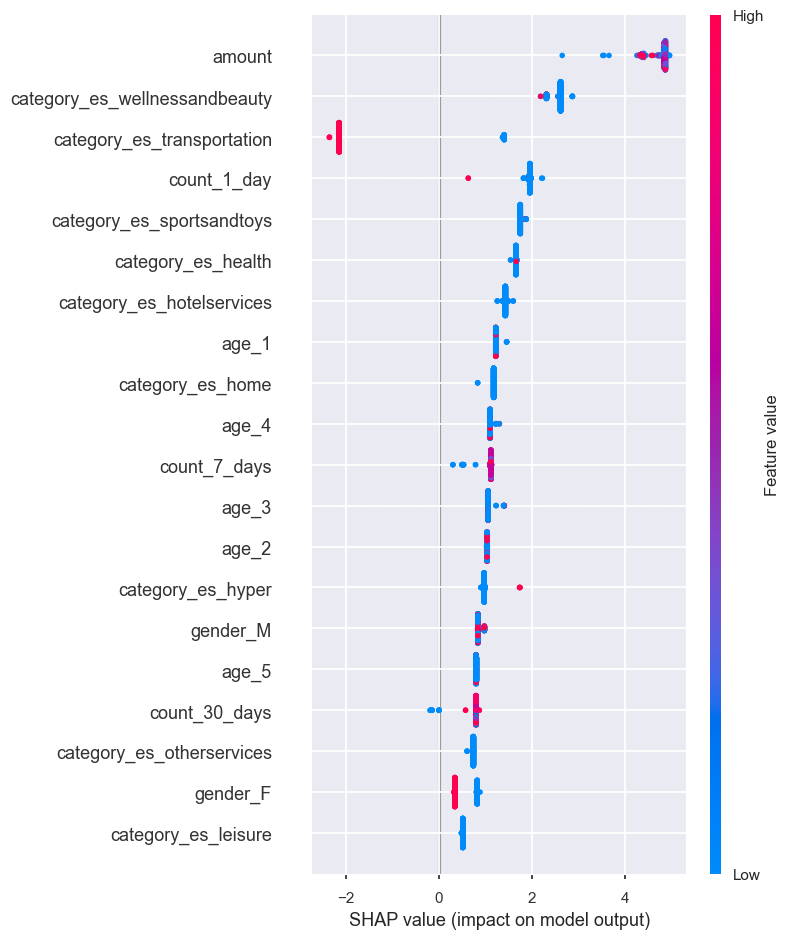

In [68]:
import shap

# Ensure SHAP visualizations render properly
shap.initjs()

# Function to plot SHAP with safe sampling
def plot_shap_summary(model, X_full, model_name, sample_size=500):
    """
    Plots SHAP summary for a given model with optional sampling to avoid heavy compute.

    Args:
        model: Trained model (can be raw model or pipeline step)
        X_full: Full feature set (DataFrame)
        model_name: Descriptive model name for display
        sample_size: Number of rows to sample (default 500)
    """
    X_sample = X_full.sample(sample_size, random_state=42)

    explainer = shap.Explainer(model)
    shap_values = explainer(X_sample)

    print(f"\n🌟 Global Feature Importance - {model_name} (Sampled {sample_size} rows)")
    shap.summary_plot(shap_values, X_sample)


# ⚡ SHAP for XGBoost
print("\nExplaining XGBoost")
model_xgb = pipe_xgb.named_steps['xgb']
plot_shap_summary(model_xgb, x_test, "XGBoost")

# ⚡ SHAP for LightGBM
print("\nExplaining LightGBM")
model_lgb = pipe_lgb.named_steps['lgb']
plot_shap_summary(model_lgb, x_test, "LightGBM")

# ⚡ SHAP for CatBoost
print("\nExplaining CatBoost")
model_cat = pipe_cat.named_steps['cat']
plot_shap_summary(model_cat, x_test, "CatBoost")


These summary plots tell us:
> X-Axis (SHAP value): The impact of that feature on the prediction.
> - Positive SHAP values push the model towards predicting fraud.
> - Negative SHAP values push it towards predicting legitimate transactions.

> Color (Feature value):
> - Red = Higher feature value
> - Blue = Lower feature value
> - Vertical Position (Features): Ordered by overall importance from top to bottom.